In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
url = 'https://docs.google.com/spreadsheets/d/1AgRLAEuIIxN1tjnYSLSiBqXasbYtN4fqD5uVcsOIhEM/export?format=csv'
median_income_df = pd.read_csv(url)
median_income_df.rename(columns={'ZipCode': 'zipcode'}, inplace=True)
median_income_df.rename(columns={'Number of Households': 'number_of_households'}, inplace=True)
median_income_df.rename(columns={'Median Income': 'median_income'}, inplace=True)
median_income_df['median_income'] = median_income_df['median_income'].replace({'\$': '', ',': ''}, regex=True).astype(float)
median_income_df['number_of_households'] = median_income_df['number_of_households'].replace({',': ''}, regex=True).astype(int)
print(median_income_df)

    zipcode  number_of_households  median_income
0     85003                  9085        49607.0
1     85004                 10548        67727.0
2     85006                 24308        54073.0
3     85007                 13939        50490.0
4     85008                 61759        57728.0
5     85009                 52420        46707.0
6     85012                  7871        74435.0
7     85013                 20662        65142.0
8     85014                 25843        64146.0
9     85015                 42594        47486.0
10    85016                 37025        80315.0
11    85017                 43226        50754.0
12    85018                 38411        85335.0
13    85019                 28102        55674.0
14    85020                 34376        74622.0
15    85021                 39835        56410.0
16    85022                 51826        63905.0
17    85023                 33097        67986.0
18    85024                 24754        91385.0
19    85027         

In [ ]:

url = 'https://docs.google.com/spreadsheets/d/1_08lOn6QcpGzOaJ24oAhqwJSTvPlCcBAQKmVo6qfaQc/export?format=csv'
overdoses_df = pd.read_csv(url)
print(overdoses_df)

    zipcode  overdoses
0     85003         14
1     85004         14
2     85006         26
3     85007         64
4     85008         42
5     85009         70
6     85012          8
7     85013          8
8     85014         18
9     85015         38
10    85016         21
11    85017         48
12    85018         21
13    85019         22
14    85020         34
15    85021         40
16    85022         20
17    85023         22
18    85024          8
19    85027         18
20    85028          5
21    85029         46
22    85031         24
23    85032         27
24    85033         25
25    85034         20
26    85035         34
27    85037         14
28    85040         31
29    85041         26
30    85042         26
31    85043         25
32    85044          0
33    85045          0
34    85048          7
35    85050          7
36    85051         41
37    85053         24
38    85054          0
39    85083          0
40    85085          9
41    85086          8
42    85087

In [ ]:
merged_df = pd.merge(median_income_df, overdoses_df, on="zipcode")
print(merged_df)

    zipcode  number_of_households  median_income  overdoses
0     85003                  9085        49607.0         14
1     85004                 10548        67727.0         14
2     85006                 24308        54073.0         26
3     85007                 13939        50490.0         64
4     85008                 61759        57728.0         42
5     85009                 52420        46707.0         70
6     85012                  7871        74435.0          8
7     85013                 20662        65142.0          8
8     85014                 25843        64146.0         18
9     85015                 42594        47486.0         38
10    85016                 37025        80315.0         21
11    85017                 43226        50754.0         48
12    85018                 38411        85335.0         21
13    85019                 28102        55674.0         22
14    85020                 34376        74622.0         34
15    85021                 39835       

            zipcode  number_of_households  median_income  overdoses
count     42.000000             42.000000      42.000000  42.000000
mean   85031.476190          34461.690476   74982.357143  22.738095
std       20.783716          16564.854061   27255.834248  16.355889
min    85003.000000           4845.000000   42177.000000   0.000000
25%    85016.250000          24419.500000   56568.750000   8.250000
50%    85028.500000          34618.500000   66045.500000  21.500000
75%    85042.750000          43793.000000   84080.000000  30.000000
max    85086.000000          68805.000000  152805.000000  70.000000
                       zipcode  number_of_households  median_income  overdoses
zipcode               1.000000              0.051152       0.632576  -0.431054
number_of_households  0.051152              1.000000      -0.254638   0.432886
median_income         0.632576             -0.254638       1.000000  -0.678487
overdoses            -0.431054              0.432886      -0.678487   1.

<Axes: xlabel='median_income'>

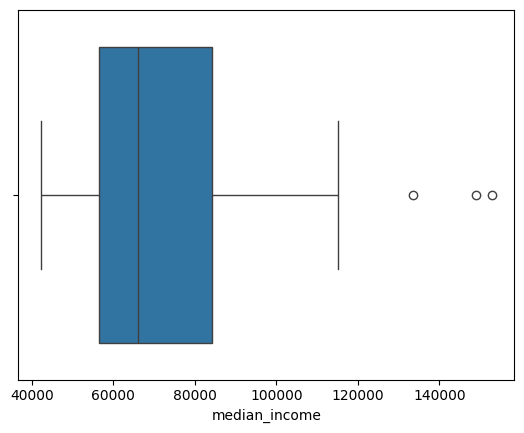

In [ ]:
print(merged_df.describe())
correlation_matrix = merged_df.corr()
print(correlation_matrix)
sns.boxplot(x="median_income", data=merged_df)

<Axes: xlabel='overdoses', ylabel='Count'>

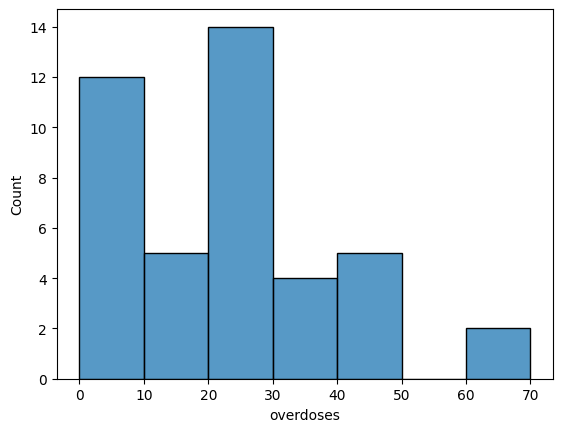

In [ ]:
sns.histplot(merged_df["overdoses"])

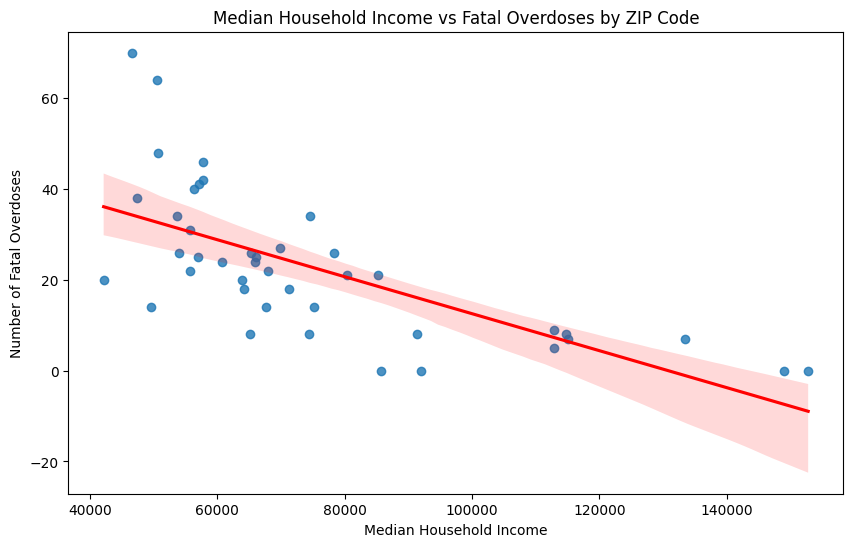

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(data=merged_df, x="median_income", y="overdoses", line_kws={"color": "red"})
plt.title("Median Household Income vs Fatal Overdoses by ZIP Code")
plt.xlabel("Median Household Income")
plt.ylabel("Number of Fatal Overdoses")
plt.show()

In [ ]:
correlation = merged_df["median_income"].corr(merged_df["overdoses"])
print(f"Correlation between median income and overdoses: {correlation}")

Correlation between median income and overdoses: -0.6784873358684328


This negative correlation suggests that as median household income increases, the number of fatal overdoses tends to decrease, although the relationship is not very strong.

## Hypothesis Testing:
Null hypothesis (H0): There is no relationship between median household income and fatal overdoses by Arizona zip code.

Alternative hypothesis (H1): There is a relationship between median household income and fatal overdoses by Arizona zip code.

You can do a t-test to compare differences between high and low income groups and a linear regression analysis.

In [ ]:
median = merged_df['median_income'].median()
high_income = merged_df[merged_df['median_income'] > median]['overdoses']
low_income = merged_df[merged_df['median_income'] <= median]['overdoses']
mean_high = high_income.mean()
mean_low = low_income.mean()

#Standard Deviations
std_high = high_income.std()
std_low = low_income.std()


n_high = len(high_income)
n_low = len(low_income)

#T-stats
pooled_std = ((std_high ** 2) / n_high + (std_low ** 2) / n_low) ** 0.5
t_stat = (mean_high - mean_low) / pooled_std

#Degrees of Freedom
df = ((std_high ** 2 / n_high + std_low ** 2 / n_low) ** 2) / \
     (((std_high ** 2 / n_high) ** 2) / (n_high - 1) + ((std_low ** 2 / n_low) ** 2) / (n_low - 1))
t_stat, df

(-4.739194839856897, 34.35864792729901)

A t-statistic of -4.739 shows a difference between the means of the high income and low income. Since the t-stat is negative, the mean number of fatal overdoses in the high-income group is lower than in the low-income group.

> Add blockquote



In [ ]:
import statsmodels.api as sm
from statsmodels.stats.power import TTestIndPower
X = sm.add_constant(merged_df['median_income'])
y = merged_df['overdoses']
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              overdoses   R-squared:                       0.460
Model:                            OLS   Adj. R-squared:                  0.447
Method:                 Least Squares   F-statistic:                     34.12
Date:                Thu, 05 Dec 2024   Prob (F-statistic):           7.90e-07
Time:                        16:57:36   Log-Likelihood:                -163.51
No. Observations:                  42   AIC:                             331.0
Df Residuals:                      40   BIC:                             334.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            53.2673      5.553      9.592      0.000      42.044      64.491
median_income    -0.0004   6.97e-05     -5.841      0.000      -0.001      -0.000
==============================================================================
Omnibus:                        7.471   Durbin-Watson:                   1.717
Prob(Omnibus):                  0.024   Jarque-Bera (JB):                6.300
Skew:                           0.785   Prob(JB):                       0.0429
Kurtosis:                       4.065   Cond. No.                     2.36e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.36e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
model.conf_int(alpha=0.05) #Confidence interval of 95%

,0,1
const,42.043803,64.490799
median_income,-0.000548,-0.000266


For every $1 increase in median income, the number of overdoses is expected to decrease by a value between 0.000266 and 0.000548

In [ ]:
analysis = TTestIndPower()
effect_size = 0.5
alpha = 0.05
power = 0.8
sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power)
sample_size

63.7656117754095

We need about 64 zip codes to detect a medium effect size (0.5) with 80% power and a significance level of 0.05. We have 42 zip codes in our study. This could show bias and increase the risk of a Type II error.


In [ ]:
effect_size = 0.5
alpha = 0.05
power = 0.62
sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power)
sample_size

42.03699214498879

Since we have 42 zip codes, we can reach approximately 62% power with a significance level of 0.05.


